In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

deliveries_df = pd.read_csv('/content/deliveries.csv')

deliveries_df['bowling_team'] = deliveries_df['bowling_team'].replace({
    'Royal Challengers Bengaluru': 'Royal Challengers Bangalore',
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Rising Pune Supergiant': 'Pune Warriors',
    'Rising Pune Supergiants': 'Pune Warriors',
    'Gujarat Titans': 'Gujarat Lions'
})

print("Columns in deliveries_df:", deliveries_df.columns.tolist())

deliveries_df['extra_runs'] = deliveries_df['extra_runs'].fillna(0)

deliveries_df['extras_type'] = deliveries_df['extras_type'].fillna('none')

deliveries_df_filtered = deliveries_df[deliveries_df['inning'].isin([1, 2])].copy()


match_extras_by_team_inning = deliveries_df_filtered.groupby(['match_id', 'bowling_team', 'inning'])['extra_runs'].sum().reset_index()

extras_summary = match_extras_by_team_inning.groupby(['bowling_team', 'inning']).agg(
    total_extras_across_all_matches=('extra_runs', 'sum'),
    average_extras_per_match=('extra_runs', 'mean')
).reset_index()

print("Total extras across all matches and average extras per match conceded by each bowling team per inning:")
display(extras_summary)

Columns in deliveries_df: ['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']
Total extras across all matches and average extras per match conceded by each bowling team per inning:


,bowling_team,inning,total_extras_across_all_matches,average_extras_per_match
0,Chennai Super Kings,1,834,7.722222
1,Chennai Super Kings,2,1008,7.753846
2,Deccan Chargers,1,294,9.187500
3,Deccan Chargers,2,365,8.488372
4,Delhi Capitals,1,1139,8.194245
5,Delhi Capitals,2,853,7.616071
6,Gujarat Lions,1,246,6.150000
7,Gujarat Lions,2,237,6.771429
8,Kochi Tuskers Kerala,1,57,8.142857
9,Kochi Tuskers Kerala,2,53,7.571429


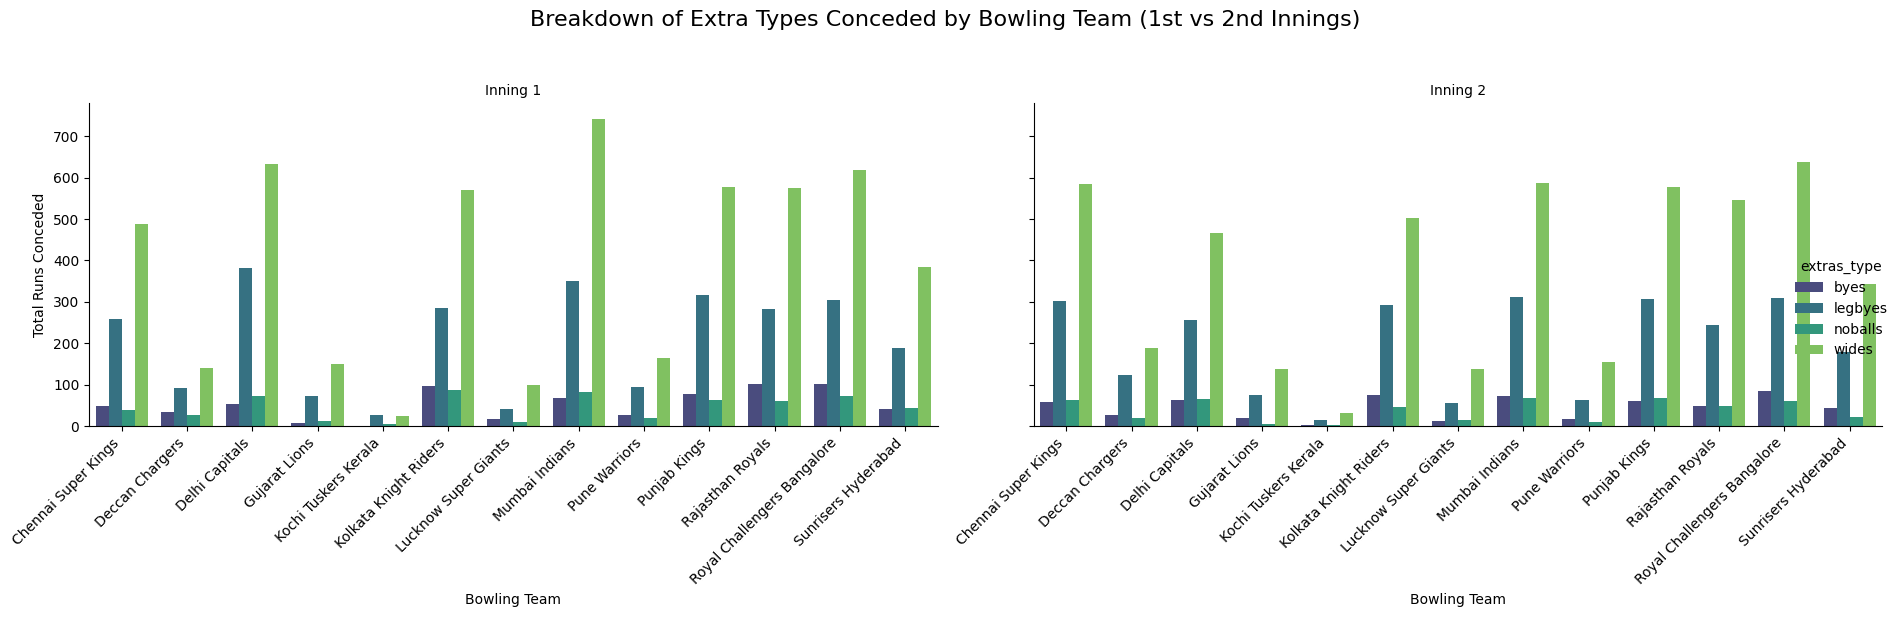

In [7]:
extras_for_viz = deliveries_df_filtered[deliveries_df_filtered['extra_runs'] > 0].copy()

viz_data_grouped = extras_for_viz.groupby(['bowling_team', 'inning', 'extras_type'])['extra_runs'].sum().reset_index()

viz_data_grouped = viz_data_grouped.rename(columns={'extra_runs': 'total_runs'})

viz_data_melted_filtered = viz_data_grouped[viz_data_grouped['extras_type'].isin(['wides', 'noballs', 'legbyes', 'byes'])]


g = sns.catplot(data=viz_data_melted_filtered, x='bowling_team',y='total_runs',hue='extras_type',col='inning',kind='bar',palette='viridis',errorbar=None,height=6, aspect=1.5
)

g.set_axis_labels('Bowling Team', 'Total Runs Conceded')
g.set_titles('Inning {col_name}')
g.set_xticklabels(rotation=45, ha='right')
plt.suptitle('Breakdown of Extra Types Conceded by Bowling Team (1st vs 2nd Innings)', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

In [8]:

overall_average_extras = extras_summary.groupby('bowling_team')['average_extras_per_match'].mean().reset_index()


team_with_fewest_extras = overall_average_extras.loc[overall_average_extras['average_extras_per_match'].idxmin()]

print(f"The team that concedes the fewest extras on average is: {team_with_fewest_extras['bowling_team']} with an average of {team_with_fewest_extras['average_extras_per_match']:.2f} extras per match.")

The team that concedes the fewest extras on average is: Gujarat Lions with an average of 6.46 extras per match.
